In [20]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

from SW_GLM import SWSolver

import sys
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config

# Load data and select ZZ

In [2]:
model = 'dummy_geneva'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "lagrangian_filtering")
os.makedirs(output_folder, exist_ok=True)

In [4]:
grid_resolution = 200
ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [5]:
zz = 0

In [6]:
u = ds.UVEL.sel(Z=zz,method='nearest').isel(time=range(8,len(ds['time'])))
v = ds.VVEL.sel(Z=zz,method='nearest').isel(time=range(8,len(ds['time'])))
w = ds.WVEL.sel(Zl=zz,method='nearest').isel(time=range(8,len(ds['time'])))

# Load solver

In [7]:
solver = SWSolver(strat=2,solve_LM=True, Nx=len(ds.XC), Ny=len(ds.YC))

Timestep dt = 0.00025
Interval time T = 1.0
Total time is 1.0
Lagrangian interval start time updated to 0.0


In [8]:
solver.set_SW_IC(A=0.5,kw=1)

./uvr_2Dturbulence_256.mat does not exist and no other initialisation given. Using zero non-wave IC.
Geostrophic linearity Fr^2/Ro = 2.5 
Wave linearity A*Ro = 0.05
Wave omega = 10.198039027185569


In [10]:
solver.solve_offline_from_velocity(ds.isel(Z=0, time=range(8,10)))

Offline GLM solve completed in 8.33 s


# Plot

In [34]:
solver.V_LMk.shape

(1, 132, 169)

TypeError: Dimensions of C (132, 169) should be one smaller than X(336) and Y(132) while using shading='flat' see help(pcolormesh)

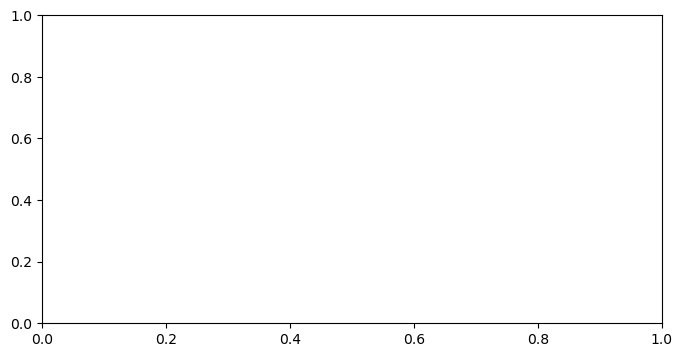

In [32]:
# Choose which version to plot
plt.rcParams['text.usetex'] = False
plt.figure(figsize=(8,4))
plt.pcolormesh(solver.xx, solver.yy, solver.V_LMk[0], shading='auto', cmap='viridis')
plt.colorbar(label='Lagrangian Mean Scalar')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrangian Mean at Mean Coordinate')
plt.show()


In [30]:
# Strategy 1, xi12
plt.figure(figsize=(8,4))
plt.quiver(solver.xx, solver.yy, solver.U_LMk[0,:,:], solver.xi12yr[0,:,:], scale=1, scale_units='xy')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Displacement ξ12')
plt.show()


AttributeError: 'SWSolver' object has no attribute 'xi12xr'

<Figure size 800x400 with 0 Axes>